In [1]:
import quanguru as qg
import numpy as np
import matplotlib.pyplot as plt

# 14 - Time dependent Hamiltonian

In previous tutorials, the system Hamiltonians were time independent, and QuanGuru provides couple different methods to describe and simulate time-dependent Hamiltonians.
In this tutorial, we demonstrate one (probably the most convenient and flexible) of these time-dependent Hamiltonian methods.

Here, we use the below single qubit Hamiltonian,

$H=f_{z}J_{z} + f_{x}(t)\sigma_{x}$

where the second term will be time dependent.

For the sake of the example, we won't use the special `Qubit` class.

## Define the system and parameters

We create a single qubit whose static Hamiltonian is set by $J_{z}$ with frequency $f_{z}=\texttt{qubFreq}$.
Then we add a second term with operator $\sigma_{x}$ and make its frequency time dependent.

The relevant information are:

- frequency: `qubFreq` for the static term and a time-dependent frequency for the drive
- operator: `Jz` for the qubit and `sigma_x` for the drive
- dimension: `2` for a qubit

We also compute useful derived quantities:

- $\Omega_R = g\,A$ is the Rabi frequency set by coupling strength and drive amplitude
- $\Delta = f_{z} - f_{\text{drive}}$ is the detuning
- $\Omega = \sqrt{\Omega_R^2 + \Delta^2}$ is the generalized Rabi frequency

In [2]:
# define parameters
qubFreq = 1
driveFreq = 2
driveAmp = 1
drivePhase = 0
couplingStrength = 1

OmegaR = couplingStrength*driveAmp
detun = qubFreq-driveFreq
Omega = np.sqrt((OmegaR**2) + (detun**2))

We set the initial state to `1` (excited state for the qubit) and choose a total simulation time of one drive period with a small step size.
We then provide a `compute` function that records the expectation value $\langle\sigma_x\rangle$ at each time step.

In [3]:
# create the qubit and set its parameters
qub = qg.QuantumSystem(operator=qg.Jz)
qub.dimension = 2
qub.frequency = qubFreq

# add the drive term 
secondTerm = qub.createTerm(operator=qg.sigmax)
secondTerm.frequency = driveFreq

# set the initial state
qub.initialState = 1  

# set the simulation time and step size
qub.simTotalTime = 2*np.pi
qub.simStepSize = 0.01

# create the operators for which we compute the expectation values
sigmaX = qg.sigmax()

# write a compute function that takes two arguments: 1) a QuantumSystem (qsys) and 2) a state
# compute whatever we want and store in .resultsDict
# here we compute the expectation value of sigmaX and store it in 'sigmax expectation' resultsDict entry
def compute(qsys, state):
    qsys.resultsDict['sigmax expectation'].append(qg.expectation(sigmaX, state))

# set the compute attribute of our qubit to compute function
qub.compute = compute

C:\Users\Josh\Desktop\Masters Project\QuanGuru Code\QuanGuru\src\quanguru\classes\QSystem.py:353: UserWarning: QuantumSystem1 type (whether it is a single or composite system) is ambiguousIf it is intentional, please ignore this
  warnings.warn(f'{self.name} type (whether it is a single or composite system) is ambiguous'+\


## Time-dependent term via a callback

We implement time dependence by assigning a function to the `timeDependency` attribute of the term.
This function receives two arguments:

- `st`: the term (or system) whose attributes we will update
- `ti`: the current simulation time

Inside the function, we set `st.frequency` to a cosine modulation with drive frequency and phase:

$f_{x}(t) = gA\cos(2\pi f_{\text{drive}}\,t + \phi)$

This approach is flexible and can be applied to any `QuantumSystem` or `Term` object.

In [4]:
def secondTermTime(st, ti):
    st.frequency = couplingStrength*driveAmp*np.cos(2*np.pi*driveFreq*ti + drivePhase)

secondTerm.timeDependency = secondTermTime

At this point, all the essential information are set, and we can run the simulation by `qub.runSimulation()`, which returns the list of states for the time evolution of our `QuantumSystem`.

In [5]:
states = qub.runSimulation()

We verify that the number of propagator exponentiations equals the step count, which confirms the integrator advanced at the requested resolution.


In [6]:
# The number of exponentiations should be equal to the step count
print(qub._freeEvol.numberOfExponentiations, qub._freeEvol.numberOfExponentiations == qub.simulation.stepCount)

628 True


Finally, we plot $\langle\sigma_x\rangle$ against time.

Text(0, 0.5, 'Sigma X Expectation Value $\\langle\\sigma_x\\rangle$')

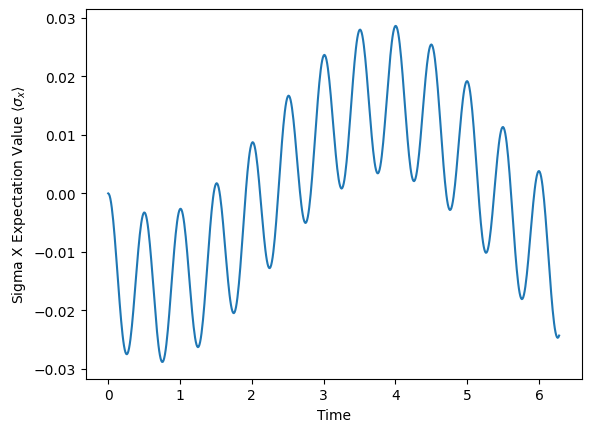

In [7]:
plt.plot(qub.simulation.timeList, qub.resultsDict['sigmax expectation'])
plt.xlabel('Time')
plt.ylabel(r'Sigma X Expectation Value $\langle\sigma_x\rangle$')